# 13 — Final Similarity Analysis

## Parte 1 — Embedding Bottleneck Audit

Obiettivo:

determinare in quale punto dell'encoder Siamese viene persa
la separabilità tra le 12 classi Tumor + Healthy.

Vengono confrontate tre rappresentazioni dello stesso encoder:

1. feature CNN 2048D
2. hidden representation 256D
3. embedding Siamese finale 128D

Per rendere confrontabili le distanze, tutte le rappresentazioni
vengono L2-normalizzate prima dell'analisi geometrica.

Per ogni spazio vengono calcolati:

- dispersione intra-classe
- distanza dal centroide della classe più vicina
- separation ratio
- media del separation ratio sulle 12 classi
- numero di classi con separation ratio > 1

Il modello non viene riaddestrato.
Viene utilizzato il miglior checkpoint Siamese k=6 Dynamic Semi-Hard.

In [1]:
# ============================================================
# IMPORTS + PATHS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_manifest.tsv"
)


CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_class_mapping.tsv"
)


VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)

TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


FCGR_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / "fcgr_k6.npy"
)


FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / "fcgr_k6_index.tsv"
)


CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_dynamic_semihard_tumor_healthy"
    / "dynamic_semihard_v3_best.pt"
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


RANDOM_STATE = 42

N_CLASSES = 12

EMBEDDING_DIM = 128


print("Device:", DEVICE)

print(
    "Checkpoint exists:",
    CHECKPOINT_PATH.exists()
)

Device: cuda
Checkpoint exists: True


In [2]:
# ============================================================
# LOAD METADATA
# ============================================================

metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={"id": str}
)

metadata["class_id"] = (
    metadata["class_id"]
    .astype(int)
)


class_mapping = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)


# ============================================================
# BALANCED TRAIN / REFERENCE
# ============================================================

full_train_metadata = (
    metadata[
        metadata["split_cluster"]
        ==
        "train"
    ]
    .copy()
    .reset_index(drop=True)
)


train_counts = (
    full_train_metadata["class_id"]
    .value_counts()
    .sort_index()
)


MIN_CLASS_SIZE = int(
    train_counts.min()
)


balanced_parts = []


for class_id in sorted(
    full_train_metadata["class_id"].unique()
):

    class_df = (
        full_train_metadata[
            full_train_metadata["class_id"]
            ==
            class_id
        ]
    )


    sampled = class_df.sample(
        n=MIN_CLASS_SIZE,
        replace=False,
        random_state=(
            RANDOM_STATE
            +
            int(class_id)
        )
    )


    balanced_parts.append(
        sampled
    )


train_metadata = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .reset_index(drop=True)
)


# ============================================================
# VALIDATION
# ============================================================

old_to_new = dict(
    zip(
        class_mapping[
            "original_class_id"
        ].astype(int),

        class_mapping[
            "class_id"
        ].astype(int)
    )
)


included_original_ids = set(
    old_to_new.keys()
)


val_original = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)


val_original["class_id"] = (
    val_original["class_id"]
    .astype(int)
)


val_metadata = (
    val_original[
        val_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)


val_metadata["original_class_id"] = (
    val_metadata["class_id"]
)


val_metadata["class_id"] = (
    val_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)


# ============================================================
# CLASS NAMES
# ============================================================

class_names = (
    class_mapping
    .sort_values("class_id")
    ["disease_clean"]
    .tolist()
)


print("=" * 72)
print("DATASET")
print("=" * 72)

print(
    "Reference:",
    len(train_metadata)
)

print(
    "Validation:",
    len(val_metadata)
)

print(
    "Classes:",
    len(class_names)
)

DATASET
Reference: 25332
Validation: 9753
Classes: 12


In [3]:
# ============================================================
# FCGR CACHE
# ============================================================

fcgr_memmap = np.load(
    FCGR_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={"id": str}
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index["id"],
        fcgr_index["fcgr_row"]
    )
)


# ============================================================
# SINGLE SAMPLE DATASET
# ============================================================

class SingleFCGRDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )


        self.fcgr_memmap = (
            fcgr_memmap
        )


        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )


        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


    def __len__(self):

        return len(
            self.metadata
        )


    def __getitem__(
        self,
        index
    ):

        x = np.array(
            self.fcgr_memmap[
                int(self.rows[index])
            ],
            dtype=np.float32,
            copy=True
        )


        return {

            "x":
                torch.from_numpy(x)
                .unsqueeze(0),

            "label":
                torch.tensor(
                    self.labels[index],
                    dtype=torch.long
                )
        }


reference_dataset = SingleFCGRDataset(
    train_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


validation_dataset = SingleFCGRDataset(
    val_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


reference_loader = DataLoader(
    reference_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)


print(
    "Reference loader:",
    len(reference_dataset)
)

print(
    "Validation loader:",
    len(validation_dataset)
)

Reference loader: 25332
Validation loader: 9753


In [4]:
# ============================================================
# CNN V3
# ============================================================

class FCGRCNNEncoderV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32, 3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8, 32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32, 32, 3,
                padding=1,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32, 64, 3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8, 64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64, 128, 3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8, 128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                128, 128, 3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8, 128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )


        self.embedding_head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        z = self.embedding_head(x)

        return F.normalize(
            z,
            p=2,
            dim=1,
            eps=1e-8
        )


class SiameseV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = (
            FCGRCNNEncoderV3(
                embedding_dim
            )
        )


model = SiameseV3(
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)


checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print("=" * 72)
print("MODEL")
print("=" * 72)

print(
    "Loaded:",
    CHECKPOINT_PATH.name
)

print(
    "Epoch:",
    checkpoint.get(
        "epoch",
        "not stored"
    )
)

MODEL
Loaded: dynamic_semihard_v3_best.pt
Epoch: 11


In [5]:
# ============================================================
# INTERMEDIATE REPRESENTATIONS
# ============================================================

@torch.no_grad()
def extract_intermediate_representations(
    encoder,
    loader
):

    encoder.eval()


    all_2048 = []
    all_256 = []
    all_128 = []

    all_labels = []


    for batch in loader:

        x = batch["x"].to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # CNN
        # ====================================================

        features = encoder.features(
            x
        )


        # [B, 128, 4, 4]
        # ->
        # [B, 2048]

        repr_2048 = torch.flatten(
            features,
            start_dim=1
        )


        # ====================================================
        # FIRST LINEAR
        # ====================================================

        linear_256 = (
            encoder.embedding_head[1]
        )

        relu = (
            encoder.embedding_head[2]
        )


        repr_256 = relu(
            linear_256(
                repr_2048
            )
        )


        # ====================================================
        # FINAL LINEAR
        # ====================================================

        linear_128 = (
            encoder.embedding_head[3]
        )


        repr_128_raw = (
            linear_128(
                repr_256
            )
        )


        repr_128 = F.normalize(
            repr_128_raw,
            p=2,
            dim=1,
            eps=1e-8
        )


        all_2048.append(
            repr_2048
            .float()
            .cpu()
            .numpy()
        )


        all_256.append(
            repr_256
            .float()
            .cpu()
            .numpy()
        )


        all_128.append(
            repr_128
            .float()
            .cpu()
            .numpy()
        )


        all_labels.append(
            batch["label"]
            .numpy()
        )


    return {

        "2048":
            np.concatenate(
                all_2048,
                axis=0
            ),

        "256":
            np.concatenate(
                all_256,
                axis=0
            ),

        "128":
            np.concatenate(
                all_128,
                axis=0
            ),

        "labels":
            np.concatenate(
                all_labels,
                axis=0
            )
    }

In [6]:
# ============================================================
# EXTRACT
# ============================================================

reference_repr = (
    extract_intermediate_representations(
        model.encoder,
        reference_loader
    )
)


validation_repr = (
    extract_intermediate_representations(
        model.encoder,
        validation_loader
    )
)


print("=" * 72)
print("REFERENCE REPRESENTATIONS")
print("=" * 72)

for level in [
    "2048",
    "256",
    "128"
]:

    print(
        f"{level}D:",
        reference_repr[level].shape
    )


print()

print("=" * 72)
print("VALIDATION REPRESENTATIONS")
print("=" * 72)

for level in [
    "2048",
    "256",
    "128"
]:

    print(
        f"{level}D:",
        validation_repr[level].shape
    )

REFERENCE REPRESENTATIONS
2048D: (25332, 2048)
256D: (25332, 256)
128D: (25332, 128)

VALIDATION REPRESENTATIONS
2048D: (9753, 2048)
256D: (9753, 256)
128D: (9753, 128)


In [7]:
# ============================================================
# L2 NORMALIZATION
# ============================================================

def l2_normalize_numpy(
    x
):

    norms = np.linalg.norm(
        x,
        axis=1,
        keepdims=True
    )


    return (
        x
        /
        (
            norms
            +
            1e-12
        )
    )


reference_normalized = {}


for level in [
    "2048",
    "256",
    "128"
]:

    reference_normalized[
        level
    ] = l2_normalize_numpy(
        reference_repr[level]
    )


print("=" * 72)
print("NORMALIZATION CHECK")
print("=" * 72)


for level in [
    "2048",
    "256",
    "128"
]:

    mean_norm = (
        np.linalg.norm(
            reference_normalized[level],
            axis=1
        )
        .mean()
    )


    print(
        f"{level}D mean norm:",
        f"{mean_norm:.6f}"
    )

NORMALIZATION CHECK
2048D mean norm: 1.000000
256D mean norm: 1.000000
128D mean norm: 1.000000


In [8]:
# ============================================================
# GEOMETRY AUDIT
# ============================================================

def analyze_embedding_geometry(
    embeddings,
    labels,
    class_names
):

    n_classes = len(
        class_names
    )


    # ========================================================
    # CENTROIDS
    # ========================================================

    centroids = []


    for class_id in range(
        n_classes
    ):

        class_embeddings = (
            embeddings[
                labels == class_id
            ]
        )


        centroid = (
            class_embeddings.mean(
                axis=0
            )
        )


        centroid = (
            centroid
            /
            (
                np.linalg.norm(
                    centroid
                )
                +
                1e-12
            )
        )


        centroids.append(
            centroid
        )


    centroids = np.stack(
        centroids
    )


    # ========================================================
    # CENTROID DISTANCES
    # ========================================================

    centroid_distances = (
        np.linalg.norm(

            centroids[:, None, :]
            -
            centroids[None, :, :],

            axis=2
        )
    )


    # ========================================================
    # CLASS ANALYSIS
    # ========================================================

    rows = []


    for class_id in range(
        n_classes
    ):

        class_embeddings = (
            embeddings[
                labels == class_id
            ]
        )


        centroid = (
            centroids[
                class_id
            ]
        )


        intra_distances = (
            np.linalg.norm(
                class_embeddings
                -
                centroid[None, :],
                axis=1
            )
        )


        other_distances = (
            centroid_distances[
                class_id
            ].copy()
        )


        other_distances[
            class_id
        ] = np.inf


        nearest_class_id = int(
            np.argmin(
                other_distances
            )
        )


        nearest_distance = float(
            other_distances[
                nearest_class_id
            ]
        )


        mean_intra = float(
            intra_distances.mean()
        )


        separation_ratio = (
            nearest_distance
            /
            (
                mean_intra
                +
                1e-12
            )
        )


        rows.append(
            {
                "class_id":
                    class_id,

                "class_name":
                    class_names[
                        class_id
                    ],

                "mean_intra_distance":
                    mean_intra,

                "nearest_class":
                    class_names[
                        nearest_class_id
                    ],

                "centroid_distance":
                    nearest_distance,

                "separation_ratio":
                    separation_ratio
            }
        )


    return (
        pd.DataFrame(rows),
        centroids,
        centroid_distances
    )

In [9]:
# ============================================================
# ANALYZE ALL REPRESENTATION LEVELS
# ============================================================

geometry_results = {}


for level in [
    "2048",
    "256",
    "128"
]:

    geometry_df, centroids, distance_matrix = (
        analyze_embedding_geometry(

            embeddings=
                reference_normalized[
                    level
                ],

            labels=
                reference_repr[
                    "labels"
                ],

            class_names=
                class_names
        )
    )


    geometry_results[level] = {

        "table":
            geometry_df,

        "centroids":
            centroids,

        "distance_matrix":
            distance_matrix
    }

In [10]:
# ============================================================
# GLOBAL BOTTLENECK SUMMARY
# ============================================================

summary_rows = []


for level in [
    "2048",
    "256",
    "128"
]:

    df = geometry_results[
        level
    ]["table"]


    summary_rows.append(
        {
            "representation":
                f"{level}D",

            "mean_intra_distance":
                df[
                    "mean_intra_distance"
                ].mean(),

            "mean_nearest_centroid_distance":
                df[
                    "centroid_distance"
                ].mean(),

            "mean_separation_ratio":
                df[
                    "separation_ratio"
                ].mean(),

            "median_separation_ratio":
                df[
                    "separation_ratio"
                ].median(),

            "classes_ratio_gt_1":
                int(
                    (
                        df[
                            "separation_ratio"
                        ]
                        >
                        1.0
                    ).sum()
                )
        }
    )


geometry_summary = pd.DataFrame(
    summary_rows
)


display(
    geometry_summary.round(4)
)

,representation,mean_intra_distance,mean_nearest_centroid_distance,mean_separation_ratio,median_separation_ratio,classes_ratio_gt_1
0,2048D,0.6605,0.2273,0.3688,0.2711,1
1,256D,0.5950,0.2028,0.3628,0.2670,1
2,128D,0.4310,0.1458,0.3545,0.2784,1


In [11]:
# ============================================================
# SEPARATION RATIO PER CLASS
# ============================================================

comparison_df = pd.DataFrame(
    {
        "class_id":
            range(
                N_CLASSES
            ),

        "class_name":
            class_names
    }
)


for level in [
    "2048",
    "256",
    "128"
]:

    df = (
        geometry_results[
            level
        ]["table"]
        .sort_values(
            "class_id"
        )
    )


    comparison_df[
        f"ratio_{level}D"
    ] = (
        df[
            "separation_ratio"
        ]
        .to_numpy()
    )


display(
    comparison_df.round(4)
)

,class_id,class_name,ratio_2048D,ratio_256D,ratio_128D
0,0,gastric cancer,0.6841,0.6411,0.6042
1,1,healthy,0.3147,0.3706,0.3821
2,2,ovarian cancer,0.3499,0.3606,0.3441
3,3,prostate cancer,0.2926,0.3010,0.2922
4,4,colorectal cancer,0.1852,0.2331,0.2626
5,5,lymphoma,0.4996,0.4803,0.4094
6,6,cervical adenocarcinoma,0.1827,0.2264,0.2645
7,7,leukemia,0.2358,0.2208,0.2274
8,8,hypopharyngeal squamous cell carcinoma,0.0710,0.0712,0.0697
9,9,glioblastoma cancer,0.2496,0.2284,0.2300


In [12]:
# ============================================================
# CHANGE THROUGH EMBEDDING HEAD
# ============================================================

comparison_df[
    "change_2048_to_128"
] = (
    comparison_df[
        "ratio_128D"
    ]
    -
    comparison_df[
        "ratio_2048D"
    ]
)


comparison_df[
    "relative_change_pct"
] = (
    100
    *
    comparison_df[
        "change_2048_to_128"
    ]
    /
    (
        comparison_df[
            "ratio_2048D"
        ]
        +
        1e-12
    )
)


display(
    comparison_df[
        [
            "class_name",
            "ratio_2048D",
            "ratio_256D",
            "ratio_128D",
            "change_2048_to_128",
            "relative_change_pct"
        ]
    ]
    .sort_values(
        "change_2048_to_128"
    )
    .round(4)
)

,class_name,ratio_2048D,ratio_256D,ratio_128D,change_2048_to_128,relative_change_pct
10,melanoma,1.2898,1.1480,1.0973,-0.1926,-14.9306
5,lymphoma,0.4996,0.4803,0.4094,-0.0902,-18.0627
0,gastric cancer,0.6841,0.6411,0.6042,-0.0799,-11.6764
9,glioblastoma cancer,0.2496,0.2284,0.2300,-0.0196,-7.8437
7,leukemia,0.2358,0.2208,0.2274,-0.0084,-3.5553
2,ovarian cancer,0.3499,0.3606,0.3441,-0.0059,-1.6726
8,hypopharyngeal squamous cell carcinoma,0.0710,0.0712,0.0697,-0.0013,-1.7977
11,hypopharynx cancer,0.0710,0.0717,0.0706,-0.0004,-0.5568
3,prostate cancer,0.2926,0.3010,0.2922,-0.0003,-0.1179
1,healthy,0.3147,0.3706,0.3821,0.0675,21.4416


In [13]:
# ============================================================
# NORMALIZE VALIDATION REPRESENTATIONS
# ============================================================

validation_normalized = {}

for level in [
    "2048",
    "256",
    "128"
]:

    validation_normalized[level] = (
        l2_normalize_numpy(
            validation_repr[level]
        )
    )


print("=" * 72)
print("VALIDATION NORMALIZATION")
print("=" * 72)

for level in [
    "2048",
    "256",
    "128"
]:

    mean_norm = np.linalg.norm(
        validation_normalized[level],
        axis=1
    ).mean()

    print(
        f"{level}D mean norm:",
        f"{mean_norm:.6f}"
    )

VALIDATION NORMALIZATION
2048D mean norm: 1.000000
256D mean norm: 1.000000
128D mean norm: 1.000000


In [14]:
# ============================================================
# TOP-K REFERENCE BANK
# ============================================================

@torch.no_grad()
def reference_bank_predict(
    query_embeddings,
    reference_embeddings,
    reference_labels,
    n_classes,
    k=20,
    batch_size=256
):

    predictions = []

    references_by_class = {}

    for class_id in range(n_classes):

        refs = reference_embeddings[
            reference_labels == class_id
        ]

        references_by_class[class_id] = (
            torch.from_numpy(refs)
            .float()
            .to(DEVICE)
        )


    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        q = (
            torch.from_numpy(
                query_embeddings[start:end]
            )
            .float()
            .to(DEVICE)
        )


        class_scores = []


        for class_id in range(
            n_classes
        ):

            refs = references_by_class[
                class_id
            ]


            # Tutti gli embedding sono L2-normalizzati.
            # cos(a,b) = a @ b

            similarity = (
                q
                @
                refs.T
            )


            # Euclidean distance su vettori normalizzati:
            #
            # ||a-b||² = 2 - 2 cos(a,b)

            distances = torch.sqrt(
                torch.clamp(
                    2.0
                    -
                    2.0
                    *
                    similarity,
                    min=0.0
                )
                +
                1e-12
            )


            nearest = torch.topk(
                distances,
                k=k,
                dim=1,
                largest=False
            ).values


            score = nearest.mean(
                dim=1
            )


            class_scores.append(
                score
            )


        class_scores = torch.stack(
            class_scores,
            dim=1
        )


        batch_predictions = (
            class_scores
            .argmin(dim=1)
        )


        predictions.append(
            batch_predictions
            .cpu()
            .numpy()
        )


    return np.concatenate(
        predictions
    )

In [15]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

In [16]:
# ============================================================
# REFERENCE-BANK COMPARISON
# ============================================================

retrieval_results = []


for level in [
    "2048",
    "256",
    "128"
]:

    print(
        f"Evaluating {level}D..."
    )


    predictions = reference_bank_predict(

        query_embeddings=
            validation_normalized[level],

        reference_embeddings=
            reference_normalized[level],

        reference_labels=
            reference_repr["labels"],

        n_classes=
            N_CLASSES,

        k=20,

        batch_size=256
    )


    accuracy = accuracy_score(
        validation_repr["labels"],
        predictions
    )


    macro_f1 = f1_score(
        validation_repr["labels"],
        predictions,
        average="macro",
        zero_division=0
    )


    balanced = balanced_accuracy_score(
        validation_repr["labels"],
        predictions
    )


    retrieval_results.append(
        {
            "representation":
                f"{level}D",

            "accuracy":
                accuracy,

            "macro_f1":
                macro_f1,

            "balanced_accuracy":
                balanced
        }
    )


retrieval_df = pd.DataFrame(
    retrieval_results
)


display(
    retrieval_df.round(4)
)

Evaluating 2048D...
Evaluating 256D...
Evaluating 128D...


,representation,accuracy,macro_f1,balanced_accuracy
0,2048D,0.3055,0.2828,0.3116
1,256D,0.3055,0.2845,0.3133
2,128D,0.3082,0.2870,0.3139


In [17]:
# ============================================================
# FINAL 128D REFERENCE BANK
# ============================================================

reference_embeddings = (
    reference_normalized["128"]
)

reference_labels = (
    reference_repr["labels"]
)

validation_embeddings = (
    validation_normalized["128"]
)

validation_labels = (
    validation_repr["labels"]
)


reference_bank = {}


for class_id in range(N_CLASSES):

    reference_bank[class_id] = (
        reference_embeddings[
            reference_labels == class_id
        ]
    )


print("=" * 72)
print("FINAL REFERENCE BANK")
print("=" * 72)

for class_id in range(N_CLASSES):

    print(
        f"{class_id:2d} | "
        f"{class_names[class_id]:45s} | "
        f"{reference_bank[class_id].shape}"
    )

FINAL REFERENCE BANK
 0 | gastric cancer                                | (2111, 128)
 1 | healthy                                       | (2111, 128)
 2 | ovarian cancer                                | (2111, 128)
 3 | prostate cancer                               | (2111, 128)
 4 | colorectal cancer                             | (2111, 128)
 5 | lymphoma                                      | (2111, 128)
 6 | cervical adenocarcinoma                       | (2111, 128)
 7 | leukemia                                      | (2111, 128)
 8 | hypopharyngeal squamous cell carcinoma        | (2111, 128)
 9 | glioblastoma cancer                           | (2111, 128)
10 | melanoma                                      | (2111, 128)
11 | hypopharynx cancer                            | (2111, 128)


In [18]:
# ============================================================
# CLASS SIMILARITY PROFILE
# ============================================================

def compute_similarity_profile(
    query_embedding,
    reference_bank,
    class_names,
    top_k=20
):

    query = np.asarray(
        query_embedding,
        dtype=np.float32
    )


    # sicurezza: L2 normalization
    query = (
        query
        /
        (
            np.linalg.norm(query)
            +
            1e-12
        )
    )


    rows = []


    for class_id in range(
        len(class_names)
    ):

        refs = (
            reference_bank[
                class_id
            ]
        )


        # Tutti L2-normalizzati:
        # dot product = cosine similarity

        similarities = (
            refs
            @
            query
        )


        k = min(
            top_k,
            len(similarities)
        )


        top_indices = np.argpartition(
            similarities,
            -k
        )[-k:]


        top_similarities = (
            similarities[
                top_indices
            ]
        )


        mean_topk = float(
            top_similarities.mean()
        )


        median_topk = float(
            np.median(
                top_similarities
            )
        )


        max_similarity = float(
            top_similarities.max()
        )


        rows.append(
            {
                "class_id":
                    class_id,

                "class_name":
                    class_names[
                        class_id
                    ],

                "mean_top20_similarity":
                    mean_topk,

                "median_top20_similarity":
                    median_topk,

                "best_reference_similarity":
                    max_similarity
            }
        )


    profile = pd.DataFrame(
        rows
    )


    profile = (
        profile
        .sort_values(
            "mean_top20_similarity",
            ascending=False
        )
        .reset_index(drop=True)
    )


    return profile

In [19]:
# ============================================================
# EXAMPLE — ONE VALIDATION SAMPLE
# ============================================================

SAMPLE_INDEX = 0


query_embedding = (
    validation_embeddings[
        SAMPLE_INDEX
    ]
)


true_class_id = int(
    validation_labels[
        SAMPLE_INDEX
    ]
)


profile = compute_similarity_profile(
    query_embedding=
        query_embedding,

    reference_bank=
        reference_bank,

    class_names=
        class_names,

    top_k=20
)


print("=" * 88)
print("SIMILARITY PROFILE")
print("=" * 88)

print(
    "True class:",
    class_names[
        true_class_id
    ]
)

print()


display(
    profile.round(4)
)

SIMILARITY PROFILE
True class: gastric cancer



,class_id,class_name,mean_top20_similarity,median_top20_similarity,best_reference_similarity
0,0,gastric cancer,0.9934,0.9933,0.9965
1,10,melanoma,0.9897,0.9887,0.9951
2,6,cervical adenocarcinoma,0.9890,0.9885,0.9931
3,1,healthy,0.9886,0.9876,0.9962
4,9,glioblastoma cancer,0.9864,0.9852,0.9947
5,7,leukemia,0.9857,0.9858,0.9906
6,5,lymphoma,0.9840,0.9835,0.9918
7,4,colorectal cancer,0.9823,0.9814,0.9899
8,8,hypopharyngeal squamous cell carcinoma,0.9748,0.9737,0.9889
9,3,prostate cancer,0.9746,0.9758,0.9942


In [20]:
# ============================================================
# FINAL PREDICTION
# ============================================================

predicted_class_id = int(
    profile.iloc[0][
        "class_id"
    ]
)


predicted_class_name = (
    profile.iloc[0][
        "class_name"
    ]
)


best_similarity = float(
    profile.iloc[0][
        "mean_top20_similarity"
    ]
)


second_similarity = float(
    profile.iloc[1][
        "mean_top20_similarity"
    ]
)


similarity_margin = (
    best_similarity
    -
    second_similarity
)


print("=" * 72)
print("FINAL SIMILARITY-BASED PREDICTION")
print("=" * 72)

print(
    "True class:",
    class_names[
        true_class_id
    ]
)

print(
    "Predicted:",
    predicted_class_name
)

print(
    "Top-1 similarity:",
    f"{best_similarity:.6f}"
)

print(
    "Top-2 similarity:",
    f"{second_similarity:.6f}"
)

print(
    "Similarity margin:",
    f"{similarity_margin:.6f}"
)

FINAL SIMILARITY-BASED PREDICTION
True class: gastric cancer
Predicted: gastric cancer
Top-1 similarity: 0.993385
Top-2 similarity: 0.989686
Similarity margin: 0.003699


In [21]:
# ============================================================
# RELATIVE AFFINITY SCORE
# ============================================================

def add_relative_affinity(
    profile
):

    profile = (
        profile.copy()
    )


    values = (
        profile[
            "mean_top20_similarity"
        ].to_numpy()
    )


    min_value = (
        values.min()
    )

    max_value = (
        values.max()
    )


    relative = (
        values
        -
        min_value
    ) / (
        max_value
        -
        min_value
        +
        1e-12
    )


    profile[
        "relative_affinity"
    ] = relative


    return profile


profile_affinity = (
    add_relative_affinity(
        profile
    )
)


display(
    profile_affinity[
        [
            "class_name",
            "mean_top20_similarity",
            "relative_affinity"
        ]
    ]
    .round(4)
)

,class_name,mean_top20_similarity,relative_affinity
0,gastric cancer,0.9934,1.0000
1,melanoma,0.9897,0.9564
2,cervical adenocarcinoma,0.9890,0.9483
3,healthy,0.9886,0.9433
4,glioblastoma cancer,0.9864,0.9173
5,leukemia,0.9857,0.9098
6,lymphoma,0.9840,0.8897
7,colorectal cancer,0.9823,0.8697
8,hypopharyngeal squamous cell carcinoma,0.9748,0.7803
9,prostate cancer,0.9746,0.7791


In [22]:
# ============================================================
# CLASS SIMILARITY MATRIX
# ============================================================

@torch.no_grad()
def compute_class_similarity_matrix(
    query_embeddings,
    reference_bank,
    n_classes,
    top_k=20,
    batch_size=256
):

    class_reference_tensors = {}

    for class_id in range(n_classes):

        class_reference_tensors[class_id] = (
            torch.from_numpy(
                reference_bank[class_id]
            )
            .float()
            .to(DEVICE)
        )


    all_scores = []


    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        queries = (
            torch.from_numpy(
                query_embeddings[start:end]
            )
            .float()
            .to(DEVICE)
        )


        batch_scores = []


        for class_id in range(n_classes):

            refs = class_reference_tensors[
                class_id
            ]


            similarities = (
                queries
                @
                refs.T
            )


            topk_values = torch.topk(
                similarities,
                k=min(
                    top_k,
                    refs.shape[0]
                ),
                dim=1,
                largest=True
            ).values


            class_score = (
                topk_values.mean(
                    dim=1
                )
            )


            batch_scores.append(
                class_score
            )


        batch_scores = torch.stack(
            batch_scores,
            dim=1
        )


        all_scores.append(
            batch_scores
            .cpu()
            .numpy()
        )


    return np.concatenate(
        all_scores,
        axis=0
    )


val_similarity_matrix = (
    compute_class_similarity_matrix(
        query_embeddings=
            validation_embeddings,

        reference_bank=
            reference_bank,

        n_classes=
            N_CLASSES,

        top_k=20
    )
)


print(
    "Similarity matrix:",
    val_similarity_matrix.shape
)

print(
    "Min:",
    val_similarity_matrix.min()
)

print(
    "Max:",
    val_similarity_matrix.max()
)

Similarity matrix: (9753, 12)
Min: 0.74917775
Max: 0.99992716


In [23]:
# ============================================================
# CLASS-SPECIFIC SCORE CALIBRATION
# ============================================================

calibration_rows = []


for class_id in range(
    N_CLASSES
):

    scores = (
        val_similarity_matrix[
            :,
            class_id
        ]
    )


    positive_scores = (
        scores[
            validation_labels
            ==
            class_id
        ]
    )


    negative_scores = (
        scores[
            validation_labels
            !=
            class_id
        ]
    )


    calibration_rows.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_names[
                    class_id
                ],

            "positive_mean":
                positive_scores.mean(),

            "positive_std":
                positive_scores.std(),

            "negative_mean":
                negative_scores.mean(),

            "negative_std":
                negative_scores.std(),

            "mean_gap":
                (
                    positive_scores.mean()
                    -
                    negative_scores.mean()
                )
        }
    )


calibration_df = pd.DataFrame(
    calibration_rows
)


display(
    calibration_df.round(5)
)

,class_id,class_name,positive_mean,positive_std,negative_mean,negative_std,mean_gap
0,0,gastric cancer,0.98233,0.01282,0.96346,0.02416,0.01887
1,1,healthy,0.98279,0.01648,0.97380,0.01729,0.00899
2,2,ovarian cancer,0.98218,0.01458,0.94438,0.05254,0.03780
3,3,prostate cancer,0.97922,0.01396,0.97448,0.01575,0.00474
4,4,colorectal cancer,0.97966,0.01227,0.96732,0.02193,0.01234
5,5,lymphoma,0.98001,0.01498,0.95501,0.05388,0.02500
6,6,cervical adenocarcinoma,0.98182,0.01351,0.95853,0.03778,0.02329
7,7,leukemia,0.98157,0.01591,0.97409,0.01499,0.00748
8,8,hypopharyngeal squamous cell carcinoma,0.98005,0.01536,0.96929,0.01666,0.01076
9,9,glioblastoma cancer,0.97762,0.01325,0.97667,0.01294,0.00095


In [24]:
# ============================================================
# CALIBRATED CLASS AFFINITY
# ============================================================

def calibrated_similarity_profile(
    raw_profile,
    calibration_df
):

    result = (
        raw_profile
        .merge(
            calibration_df[
                [
                    "class_id",
                    "positive_mean",
                    "negative_mean",
                    "mean_gap"
                ]
            ],
            on="class_id",
            how="left"
        )
    )


    result[
        "calibrated_affinity"
    ] = (

        result[
            "mean_top20_similarity"
        ]
        -
        result[
            "negative_mean"
        ]

    ) / (

        result[
            "positive_mean"
        ]
        -
        result[
            "negative_mean"
        ]
        +
        1e-12
    )


    result[
        "calibrated_affinity"
    ] = np.clip(
        result[
            "calibrated_affinity"
        ],
        0.0,
        1.0
    )


    return (
        result
        .sort_values(
            "calibrated_affinity",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [25]:
calibrated_profile = (
    calibrated_similarity_profile(
        raw_profile=profile,
        calibration_df=calibration_df
    )
)


display(
    calibrated_profile[
        [
            "class_name",
            "mean_top20_similarity",
            "negative_mean",
            "positive_mean",
            "calibrated_affinity"
        ]
    ]
    .round(4)
)

,class_name,mean_top20_similarity,negative_mean,positive_mean,calibrated_affinity
0,gastric cancer,0.9934,0.9635,0.9823,1.0000
1,melanoma,0.9897,0.9414,0.9890,1.0000
2,cervical adenocarcinoma,0.9890,0.9585,0.9818,1.0000
3,healthy,0.9886,0.9738,0.9828,1.0000
4,glioblastoma cancer,0.9864,0.9767,0.9776,1.0000
5,leukemia,0.9857,0.9741,0.9816,1.0000
6,lymphoma,0.9840,0.9550,0.9800,1.0000
7,colorectal cancer,0.9823,0.9673,0.9797,1.0000
8,hypopharyngeal squamous cell carcinoma,0.9748,0.9693,0.9800,0.5079
9,prostate cancer,0.9746,0.9745,0.9792,0.0351


In [26]:
# ============================================================
# FULL VALIDATION — RAW COSINE SIMILARITY RANKING
# ============================================================

similarity_ranking = np.argsort(
    -val_similarity_matrix,
    axis=1
)


top1_predictions = (
    similarity_ranking[:, 0]
)


top1_scores = (
    np.take_along_axis(
        val_similarity_matrix,
        similarity_ranking[:, :1],
        axis=1
    )[:, 0]
)


top2_scores = (
    np.take_along_axis(
        val_similarity_matrix,
        similarity_ranking[:, 1:2],
        axis=1
    )[:, 0]
)


top1_top2_margin = (
    top1_scores
    -
    top2_scores
)


correct = (
    top1_predictions
    ==
    validation_labels
)


print("=" * 72)
print("FULL VALIDATION — RAW SIMILARITY")
print("=" * 72)

print(
    "Samples:",
    len(validation_labels)
)

print(
    "Top-1 accuracy:",
    correct.mean()
)

print(
    "Mean Top-1 similarity:",
    top1_scores.mean()
)

print(
    "Mean Top-2 similarity:",
    top2_scores.mean()
)

print(
    "Mean Top1-Top2 margin:",
    top1_top2_margin.mean()
)

FULL VALIDATION — RAW SIMILARITY
Samples: 9753
Top-1 accuracy: 0.307392597149595
Mean Top-1 similarity: 0.9859947
Mean Top-2 similarity: 0.98418957
Mean Top1-Top2 margin: 0.0018051008


In [27]:
# ============================================================
# TOP-K ACCURACY
# ============================================================

def topk_accuracy(
    ranking,
    labels,
    k
):

    topk = ranking[
        :,
        :k
    ]


    return np.mean(
        np.any(
            topk
            ==
            labels[:, None],
            axis=1
        )
    )


top1_acc = topk_accuracy(
    similarity_ranking,
    validation_labels,
    1
)

top3_acc = topk_accuracy(
    similarity_ranking,
    validation_labels,
    3
)

top5_acc = topk_accuracy(
    similarity_ranking,
    validation_labels,
    5
)


print("=" * 72)
print("TOP-K CLASS ASSOCIATION")
print("=" * 72)

print(
    "Top-1:",
    f"{top1_acc:.4f}"
)

print(
    "Top-3:",
    f"{top3_acc:.4f}"
)

print(
    "Top-5:",
    f"{top5_acc:.4f}"
)

TOP-K CLASS ASSOCIATION
Top-1: 0.3074
Top-3: 0.6520
Top-5: 0.8220


In [28]:
# ============================================================
# TRUE CLASS RANK
# ============================================================

true_class_rank = np.empty(
    len(validation_labels),
    dtype=np.int64
)


for i in range(
    len(validation_labels)
):

    true_class_rank[i] = (
        np.where(
            similarity_ranking[i]
            ==
            validation_labels[i]
        )[0][0]
        +
        1
    )


print("=" * 72)
print("TRUE CLASS RANK")
print("=" * 72)

print(
    "Mean rank:",
    true_class_rank.mean()
)

print(
    "Median rank:",
    np.median(
        true_class_rank
    )
)

print(
    "Rank 1:",
    np.mean(
        true_class_rank == 1
    )
)

print(
    "Rank <= 3:",
    np.mean(
        true_class_rank <= 3
    )
)

print(
    "Rank <= 5:",
    np.mean(
        true_class_rank <= 5
    )
)

TRUE CLASS RANK
Mean rank: 3.271711268327694
Median rank: 2.0
Rank 1: 0.307392597149595
Rank <= 3: 0.6520045114323798
Rank <= 5: 0.8220034861068389


In [29]:
# ============================================================
# SIMILARITY MARGIN ANALYSIS
# ============================================================

correct_margins = (
    top1_top2_margin[
        correct
    ]
)


incorrect_margins = (
    top1_top2_margin[
        ~correct
    ]
)


print("=" * 72)
print("TOP1-TOP2 MARGIN")
print("=" * 72)

print("CORRECT")

print(
    "Mean:",
    correct_margins.mean()
)

print(
    "Median:",
    np.median(
        correct_margins
    )
)

print()

print("INCORRECT")

print(
    "Mean:",
    incorrect_margins.mean()
)

print(
    "Median:",
    np.median(
        incorrect_margins
    )
)

TOP1-TOP2 MARGIN
CORRECT
Mean: 0.0018871583
Median: 0.0013687313

INCORRECT
Mean: 0.0017686823
Median: 0.0012179613


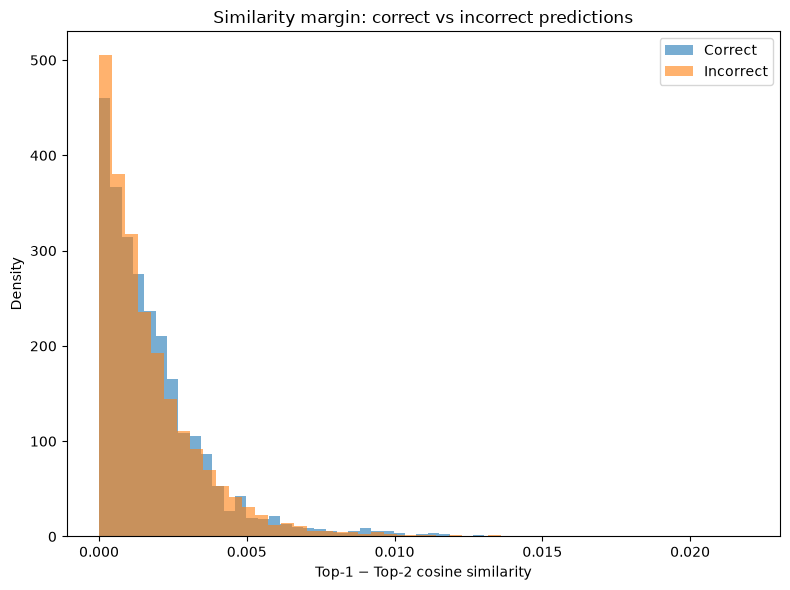

In [30]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.hist(
    correct_margins,
    bins=50,
    alpha=0.6,
    label="Correct",
    density=True
)


ax.hist(
    incorrect_margins,
    bins=50,
    alpha=0.6,
    label="Incorrect",
    density=True
)


ax.set_xlabel(
    "Top-1 − Top-2 cosine similarity"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Similarity margin: correct vs incorrect predictions"
)

ax.legend()


plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# EXAMPLE PROFILES — MULTIPLE VALIDATION SAMPLES
# ============================================================

correct_indices = np.where(
    correct
)[0]


incorrect_indices = np.where(
    ~correct
)[0]


example_indices = np.concatenate(
    [
        correct_indices[:3],
        incorrect_indices[:3]
    ]
)


for sample_index in example_indices:

    profile = compute_similarity_profile(
        query_embedding=
            validation_embeddings[
                sample_index
            ],

        reference_bank=
            reference_bank,

        class_names=
            class_names,

        top_k=20
    )


    true_id = int(
        validation_labels[
            sample_index
        ]
    )


    predicted_id = int(
        profile.iloc[0][
            "class_id"
        ]
    )


    print("=" * 90)

    print(
        "Sample:",
        sample_index
    )

    print(
        "True:",
        class_names[
            true_id
        ]
    )

    print(
        "Predicted:",
        class_names[
            predicted_id
        ]
    )

    print(
        "Correct:",
        true_id
        ==
        predicted_id
    )

    print()


    display(
        profile[
            [
                "class_name",
                "mean_top20_similarity"
            ]
        ]
        .head(5)
        .round(5)
    )

Sample: 0
True: gastric cancer
Predicted: gastric cancer
Correct: True



,class_name,mean_top20_similarity
0,gastric cancer,0.99338
1,melanoma,0.98969
2,cervical adenocarcinoma,0.98900
3,healthy,0.98858
4,glioblastoma cancer,0.98637


Sample: 1
True: gastric cancer
Predicted: gastric cancer
Correct: True



,class_name,mean_top20_similarity
0,gastric cancer,0.97467
1,colorectal cancer,0.97257
2,cervical adenocarcinoma,0.97091
3,healthy,0.97045
4,lymphoma,0.96343


Sample: 2
True: gastric cancer
Predicted: gastric cancer
Correct: True



...

,class_name,mean_top20_similarity
0,hypopharyngeal squamous cell carcinoma,0.97261
1,leukemia,0.97137
2,hypopharynx cancer,0.97133
3,gastric cancer,0.96877
4,glioblastoma cancer,0.96774


Sample: 5
True: gastric cancer
Predicted: colorectal cancer
Correct: False



,class_name,mean_top20_similarity
0,colorectal cancer,0.99068
1,cervical adenocarcinoma,0.99050
2,lymphoma,0.98730
3,prostate cancer,0.98491
4,gastric cancer,0.97760


Sample: 6
True: gastric cancer
Predicted: leukemia
Correct: False



,class_name,mean_top20_similarity
0,leukemia,0.99062
1,glioblastoma cancer,0.98900
2,healthy,0.98888
3,cervical adenocarcinoma,0.98825
4,gastric cancer,0.98806


In [32]:
# ============================================================
# PER-CLASS TOP-K VALIDATION PERFORMANCE
# ============================================================

per_class_rows = []

for class_id in range(N_CLASSES):

    mask = (
        validation_labels
        ==
        class_id
    )

    class_ranking = (
        similarity_ranking[
            mask
        ]
    )

    class_labels = (
        validation_labels[
            mask
        ]
    )

    per_class_rows.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_names[
                    class_id
                ],

            "support":
                int(
                    mask.sum()
                ),

            "top1":
                topk_accuracy(
                    class_ranking,
                    class_labels,
                    1
                ),

            "top3":
                topk_accuracy(
                    class_ranking,
                    class_labels,
                    3
                ),

            "top5":
                topk_accuracy(
                    class_ranking,
                    class_labels,
                    5
                ),

            "mean_true_rank":
                true_class_rank[
                    mask
                ].mean(),

            "median_true_rank":
                np.median(
                    true_class_rank[
                        mask
                    ]
                )
        }
    )


per_class_topk_df = pd.DataFrame(
    per_class_rows
)


display(
    per_class_topk_df.round(4)
)

,class_id,class_name,support,top1,top3,top5,mean_true_rank,median_true_rank
0,0,gastric cancer,1000,0.5170,0.7890,0.9100,2.4280,1.0
1,1,healthy,1000,0.1930,0.6000,0.7470,3.9720,3.0
2,2,ovarian cancer,1000,0.4940,0.6920,0.8640,2.9150,2.0
3,3,prostate cancer,1000,0.0870,0.5010,0.7980,3.8550,3.0
4,4,colorectal cancer,1000,0.3070,0.6740,0.8560,3.0450,2.0
5,5,lymphoma,1000,0.4050,0.6770,0.8040,3.1130,3.0
6,6,cervical adenocarcinoma,1000,0.2560,0.7200,0.8930,2.9570,2.0
7,7,leukemia,1000,0.1900,0.5880,0.7500,3.7160,3.0
8,8,hypopharyngeal squamous cell carcinoma,585,0.2239,0.6701,0.8034,3.5368,2.0
9,9,glioblastoma cancer,505,0.1327,0.4594,0.7267,3.9545,4.0


In [33]:
# ============================================================
# FINAL TEST SET — SAME LOGIC AS VALIDATION
# ============================================================

test_original = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)


test_original["class_id"] = (
    test_original["class_id"]
    .astype(int)
)


# ============================================================
# KEEP ONLY THE 12 FINAL CLASSES
# ============================================================

test_metadata = (
    test_original[
        test_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# ORIGINAL -> 12-CLASS REMAPPING
# ============================================================

test_metadata[
    "original_class_id"
] = (
    test_metadata[
        "class_id"
    ]
)


test_metadata[
    "class_id"
] = (
    test_metadata[
        "original_class_id"
    ]
    .map(old_to_new)
    .astype(int)
)


# ============================================================
# FCGR CHECK
# ============================================================

missing_mask = (
    ~test_metadata["id"]
    .astype(str)
    .isin(id_to_fcgr_row)
)


missing_test = int(
    missing_mask.sum()
)


print("=" * 72)
print("FINAL TEST SET")
print("=" * 72)

print(
    "Original test pool:",
    len(test_original)
)

print(
    "12-class test samples:",
    len(test_metadata)
)

print(
    "Missing FCGR:",
    missing_test
)

print()

print(
    "Class distribution:"
)

print(
    test_metadata[
        "class_id"
    ]
    .value_counts()
    .sort_index()
)


if missing_test > 0:

    print()
    print(
        "First missing IDs:"
    )

    display(
        test_metadata.loc[
            missing_mask,
            [
                "id",
                "original_class_id",
                "class_id"
            ]
        ]
        .head(20)
    )


assert (
    missing_test == 0
), (
    f"{missing_test} test samples "
    "are missing from the FCGR cache."
)

FINAL TEST SET
Original test pool: 11070
12-class test samples: 8923
Missing FCGR: 0

Class distribution:
class_id
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8      288
9      296
10     225
11     114
Name: count, dtype: int64


In [34]:
test_dataset = SingleFCGRDataset(
    test_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(
        DEVICE.type
        ==
        "cuda"
    )
)


test_repr = (
    extract_intermediate_representations(
        model.encoder,
        test_loader
    )
)


test_embeddings = (
    l2_normalize_numpy(
        test_repr["128"]
    )
)


test_labels = (
    test_repr["labels"]
)


print(
    "Test embeddings:",
    test_embeddings.shape
)

print(
    "Test labels:",
    test_labels.shape
)

Test embeddings: (8923, 128)
Test labels: (8923,)


In [35]:
# ============================================================
# FINAL TEST — COSINE SIMILARITY MATRIX
# ============================================================

test_similarity_matrix = (
    compute_class_similarity_matrix(

        query_embeddings=
            test_embeddings,

        reference_bank=
            reference_bank,

        n_classes=
            N_CLASSES,

        top_k=20
    )
)


test_ranking = np.argsort(
    -test_similarity_matrix,
    axis=1
)


test_predictions = (
    test_ranking[
        :,
        0
    ]
)


print(
    "Similarity matrix:",
    test_similarity_matrix.shape
)

Similarity matrix: (8923, 12)


In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)


test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)


test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)


test_balanced_accuracy = (
    balanced_accuracy_score(
        test_labels,
        test_predictions
    )
)


test_top3 = topk_accuracy(
    test_ranking,
    test_labels,
    3
)


test_top5 = topk_accuracy(
    test_ranking,
    test_labels,
    5
)


# ============================================================
# TRUE CLASS RANK
# ============================================================

test_true_rank = np.empty(
    len(test_labels),
    dtype=np.int64
)


for i in range(
    len(test_labels)
):

    test_true_rank[i] = (
        np.where(
            test_ranking[i]
            ==
            test_labels[i]
        )[0][0]
        +
        1
    )


print("=" * 72)
print("FINAL TEST RESULTS")
print("=" * 72)

print(
    "Top-1 Accuracy:",
    f"{test_accuracy:.4f}"
)

print(
    "Macro-F1:",
    f"{test_macro_f1:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{test_balanced_accuracy:.4f}"
)

print()

print(
    "Top-3 Accuracy:",
    f"{test_top3:.4f}"
)

print(
    "Top-5 Accuracy:",
    f"{test_top5:.4f}"
)

print()

print(
    "Mean true-class rank:",
    f"{test_true_rank.mean():.4f}"
)

print(
    "Median true-class rank:",
    np.median(
        test_true_rank
    )
)

FINAL TEST RESULTS
Top-1 Accuracy: 0.3158
Macro-F1: 0.2784
Balanced Accuracy: 0.3197

Top-3 Accuracy: 0.6583
Top-5 Accuracy: 0.8253

Mean true-class rank: 3.2449
Median true-class rank: 2.0


In [37]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                        gastric cancer     0.3722    0.5140    0.4318      1000
                               healthy     0.5655    0.1640    0.2543      1000
                        ovarian cancer     0.4262    0.4940    0.4576      1000
                       prostate cancer     0.3089    0.0970    0.1476      1000
                     colorectal cancer     0.3121    0.3380    0.3245      1000
                              lymphoma     0.3310    0.4270    0.3729      1000
               cervical adenocarcinoma     0.2876    0.2640    0.2753      1000
                              leukemia     0.4102    0.2330    0.2972      1000
hypopharyngeal squamous cell carcinoma     0.1758    0.2014    0.1877       288
                   glioblastoma cancer     0.1049    0.1655    0.1284       296
                              melanoma     0.2526    0.6578    0.3650       225
                    hypopharynx cancer 

In [38]:
# ============================================================
# BALANCED TOP-K ACCURACY
# = MACRO RECALL@K
# ============================================================

def balanced_topk_accuracy(
    ranking,
    labels,
    n_classes,
    k
):

    per_class_recall = []

    for class_id in range(n_classes):

        class_mask = (
            labels
            ==
            class_id
        )

        class_ranking = (
            ranking[
                class_mask,
                :k
            ]
        )

        class_labels = (
            labels[
                class_mask
            ]
        )

        correct_topk = np.any(
            class_ranking
            ==
            class_labels[:, None],
            axis=1
        )

        recall_k = (
            correct_topk.mean()
        )

        per_class_recall.append(
            recall_k
        )


    balanced_topk = np.mean(
        per_class_recall
    )

    return (
        balanced_topk,
        np.array(
            per_class_recall
        )
    )

In [39]:
# ============================================================
# VALIDATION — BALANCED TOP-K
# ============================================================

val_bal_top1, _ = (
    balanced_topk_accuracy(
        ranking=similarity_ranking,
        labels=validation_labels,
        n_classes=N_CLASSES,
        k=1
    )
)

val_bal_top3, _ = (
    balanced_topk_accuracy(
        ranking=similarity_ranking,
        labels=validation_labels,
        n_classes=N_CLASSES,
        k=3
    )
)

val_bal_top5, _ = (
    balanced_topk_accuracy(
        ranking=similarity_ranking,
        labels=validation_labels,
        n_classes=N_CLASSES,
        k=5
    )
)


print("=" * 72)
print("VALIDATION — BALANCED TOP-K ACCURACY")
print("=" * 72)

print(
    "Balanced Top-1:",
    f"{val_bal_top1:.4f}"
)

print(
    "Balanced Top-3:",
    f"{val_bal_top3:.4f}"
)

print(
    "Balanced Top-5:",
    f"{val_bal_top5:.4f}"
)

VALIDATION — BALANCED TOP-K ACCURACY
Balanced Top-1: 0.3137
Balanced Top-3: 0.6542
Balanced Top-5: 0.8199


In [40]:
# ============================================================
# TEST — BALANCED TOP-K
# ============================================================

test_bal_top1, test_recall_top1 = (
    balanced_topk_accuracy(
        ranking=test_ranking,
        labels=test_labels,
        n_classes=N_CLASSES,
        k=1
    )
)

test_bal_top3, test_recall_top3 = (
    balanced_topk_accuracy(
        ranking=test_ranking,
        labels=test_labels,
        n_classes=N_CLASSES,
        k=3
    )
)

test_bal_top5, test_recall_top5 = (
    balanced_topk_accuracy(
        ranking=test_ranking,
        labels=test_labels,
        n_classes=N_CLASSES,
        k=5
    )
)


print("=" * 72)
print("FINAL TEST — BALANCED TOP-K ACCURACY")
print("=" * 72)

print(
    "Balanced Top-1:",
    f"{test_bal_top1:.4f}"
)

print(
    "Balanced Top-3:",
    f"{test_bal_top3:.4f}"
)

print(
    "Balanced Top-5:",
    f"{test_bal_top5:.4f}"
)

FINAL TEST — BALANCED TOP-K ACCURACY
Balanced Top-1: 0.3197
Balanced Top-3: 0.6561
Balanced Top-5: 0.8209


In [41]:
# ============================================================
# TEST — PER-CLASS RECALL@K
# ============================================================

balanced_ranking_df = pd.DataFrame(
    {
        "class_id":
            range(N_CLASSES),

        "class_name":
            class_names,

        "recall_at_1":
            test_recall_top1,

        "recall_at_3":
            test_recall_top3,

        "recall_at_5":
            test_recall_top5
    }
)


display(
    balanced_ranking_df.round(4)
)

,class_id,class_name,recall_at_1,recall_at_3,recall_at_5
0,0,gastric cancer,0.5140,0.7690,0.8780
1,1,healthy,0.1640,0.6240,0.7730
2,2,ovarian cancer,0.4940,0.6790,0.8390
3,3,prostate cancer,0.0970,0.5070,0.8120
4,4,colorectal cancer,0.3380,0.6750,0.8590
5,5,lymphoma,0.4270,0.6960,0.8280
6,6,cervical adenocarcinoma,0.2640,0.7250,0.8740
7,7,leukemia,0.2330,0.6070,0.7550
8,8,hypopharyngeal squamous cell carcinoma,0.2014,0.6319,0.8125
9,9,glioblastoma cancer,0.1655,0.5405,0.7905


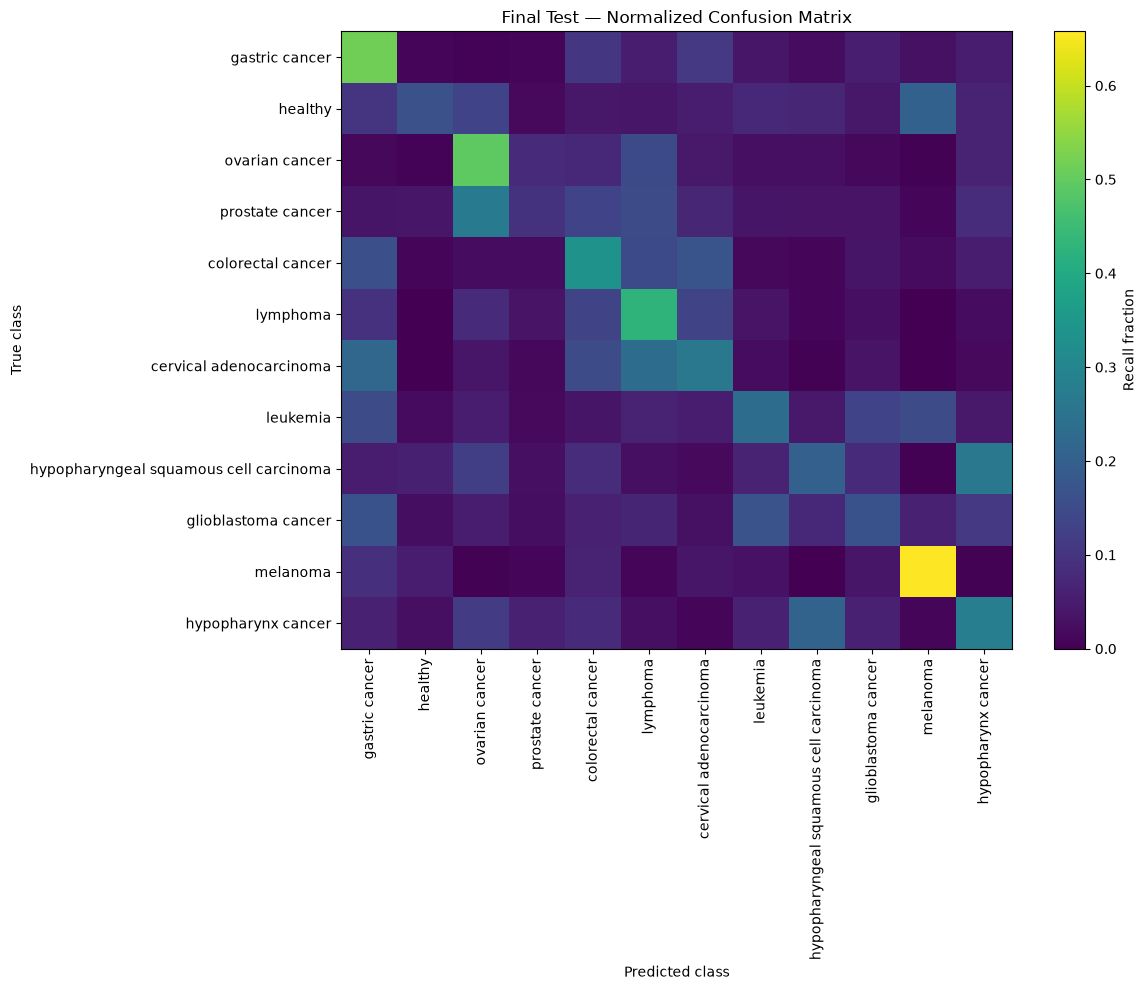

In [42]:
# ============================================================
# FINAL TEST CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=np.arange(N_CLASSES)
)


cm_normalized = (
    cm
    /
    (
        cm.sum(
            axis=1,
            keepdims=True
        )
        +
        1e-12
    )
)


fig, ax = plt.subplots(
    figsize=(12, 10)
)


im = ax.imshow(
    cm_normalized,
    aspect="auto"
)


ax.set_xticks(
    np.arange(N_CLASSES)
)

ax.set_yticks(
    np.arange(N_CLASSES)
)


ax.set_xticklabels(
    class_names,
    rotation=90
)

ax.set_yticklabels(
    class_names
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "Final Test — Normalized Confusion Matrix"
)


fig.colorbar(
    im,
    ax=ax,
    label="Recall fraction"
)


plt.tight_layout()
plt.show()

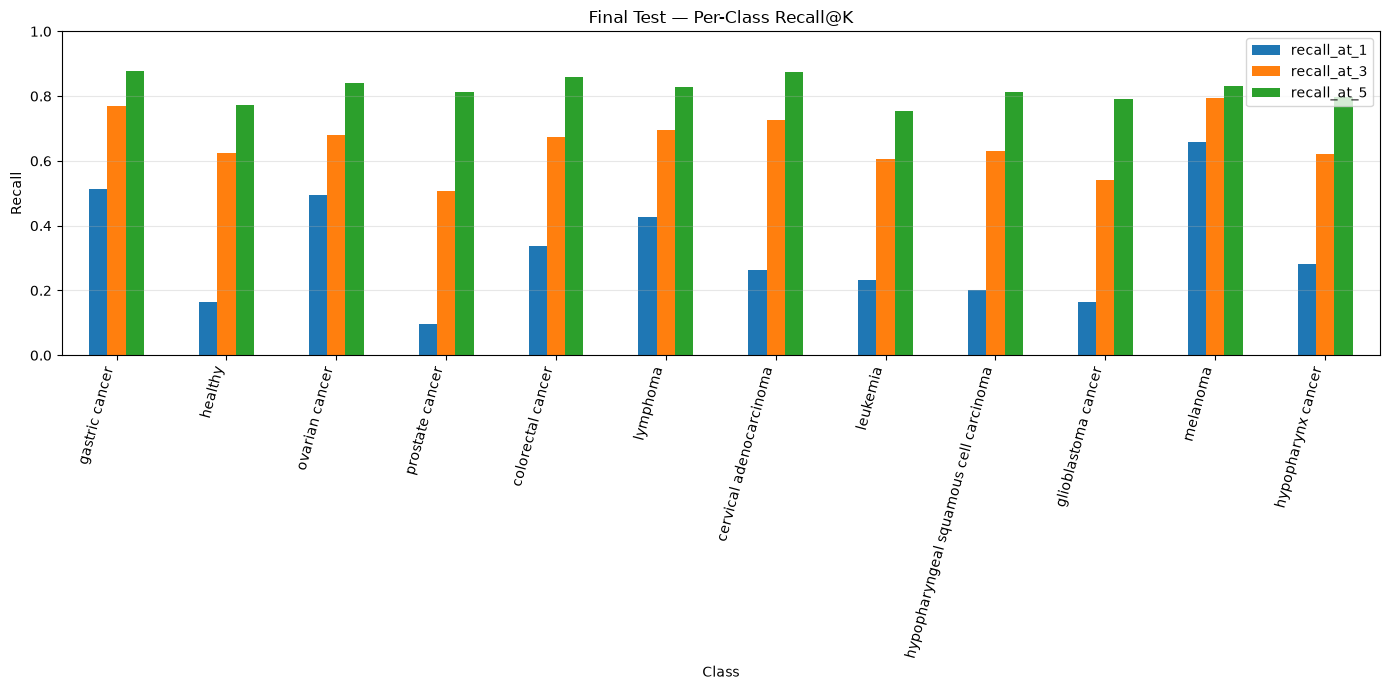

In [47]:
# ============================================================
# FINAL TEST — PER-CLASS RECALL@K
# ============================================================

plot_df = (
    balanced_ranking_df
    .set_index("class_name")
    [
        [
            "recall_at_1",
            "recall_at_3",
            "recall_at_5"
        ]
    ]
)


ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_ylabel("Recall")
ax.set_xlabel("Class")
ax.set_ylim(0, 1)

ax.set_title(
    "Final Test — Per-Class Recall@K"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "final_test_per_class_recall_at_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# ============================================================
# FINAL ABLATION SUMMARY
# ============================================================

ablation_df = pd.DataFrame(
    [
        {
            "experiment": "CNN k6 random",
            "type": "Baseline",
            "val_auc": 0.661052,
            "multiclass_acc": 0.279606,
            "macro_f1": 0.243436
        },

        {
            "experiment": "CNN k6 semi-hard + Top20",
            "type": "Negative mining",
            "val_auc": 0.664895,
            "multiclass_acc": 0.308110,
            "macro_f1": 0.286888
        },

        {
            "experiment": "CNN k7 random + Top20",
            "type": "FCGR resolution",
            "val_auc": 0.665868,
            "multiclass_acc": 0.303086,
            "macro_f1": 0.284334
        },

        {
            "experiment": "Residual CNN",
            "type": "Encoder",
            "val_auc": 0.656950,
            "multiclass_acc": 0.269968,
            "macro_f1": 0.235231
        },

        {
            "experiment": "CNN + Transformer",
            "type": "Encoder",
            "val_auc": 0.6313,
            "multiclass_acc": np.nan,
            "macro_f1": np.nan
        },

        {
            "experiment": "ViT from scratch",
            "type": "Encoder",
            "val_auc": 0.6284,
            "multiclass_acc": np.nan,
            "macro_f1": np.nan
        }
    ]
)


display(
    ablation_df.round(4)
)

,experiment,type,val_auc,multiclass_acc,macro_f1
0,CNN k6 random,Baseline,0.6611,0.2796,0.2434
1,CNN k6 semi-hard + Top20,Negative mining,0.6649,0.3081,0.2869
2,CNN k7 random + Top20,FCGR resolution,0.6659,0.3031,0.2843
3,Residual CNN,Encoder,0.6570,0.2700,0.2352
4,CNN + Transformer,Encoder,0.6313,NaN,NaN
5,ViT from scratch,Encoder,0.6284,NaN,NaN


In [45]:
# ============================================================
# SAVE FINAL RESULTS
# ============================================================

import json


FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_similarity_analysis"
)


FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


final_results = {

    "model": {
        "fcgr_k": 6,
        "encoder": "CNN_V3",
        "embedding_dim": 128,
        "embedding_normalization": "L2",
        "training_loss": "Euclidean Contrastive Loss",
        "negative_mining": "Dynamic Semi-Hard",
        "inference": "Top-20 cosine similarity reference bank"
    },

    "test": {
        "top1_accuracy":
            float(test_accuracy),

        "balanced_top1":
            float(test_bal_top1),

        "top3_accuracy":
            float(test_top3),

        "balanced_top3":
            float(test_bal_top3),

        "top5_accuracy":
            float(test_top5),

        "balanced_top5":
            float(test_bal_top5),

        "macro_f1":
            float(test_macro_f1),

        "balanced_accuracy":
            float(test_balanced_accuracy),

        "mean_true_class_rank":
            float(test_true_rank.mean()),

        "median_true_class_rank":
            float(
                np.median(
                    test_true_rank
                )
            )
    }
}


with open(
    FINAL_RESULTS_DIR
    / "final_test_results.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )


balanced_ranking_df.to_csv(
    FINAL_RESULTS_DIR
    / "test_per_class_recall_at_k.csv",
    index=False
)


ablation_df.to_csv(
    FINAL_RESULTS_DIR
    / "ablation_summary.csv",
    index=False
)


print(
    "Saved to:",
    FINAL_RESULTS_DIR
)

Saved to: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_similarity_analysis


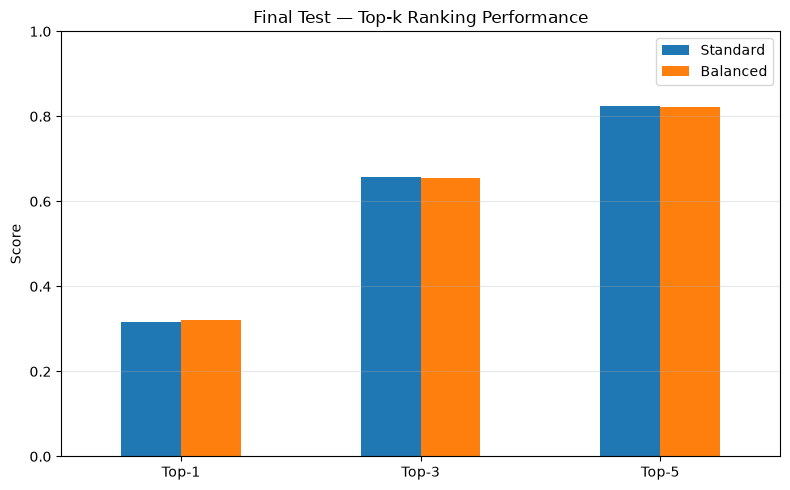

In [46]:
# ============================================================
# FINAL TEST — GLOBAL TOP-K VS BALANCED TOP-K
# ============================================================

topk_plot_df = pd.DataFrame(
    {
        "Metric": [
            "Top-1",
            "Top-3",
            "Top-5"
        ],
        "Standard": [
            test_accuracy,
            test_top3,
            test_top5
        ],
        "Balanced": [
            test_bal_top1,
            test_bal_top3,
            test_bal_top5
        ]
    }
)


ax = (
    topk_plot_df
    .set_index("Metric")
    .plot(
        kind="bar",
        figsize=(8, 5)
    )
)


ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)

ax.set_title(
    "Final Test — Top-k Ranking Performance"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "final_test_topk_balanced.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()